In [1]:
from PYME.IO.image import ImageStack
from double_helix.DoubleGaussFit import Detector as new_detector
from double_helix.FitFactories.DoubleHelixFit_Theta import Detector as old_detector
import matplotlib.pyplot as plt
from scipy import ndimage
# %matplotlib widget
# plt.set_loglevel("warning")
import numpy as np
import os
from PYME.recipes.processing import BackgroundSubtractionMovingPercentile

In [2]:
im = ImageStack(filename = "F:/Toxoplasma_Fixed_Cell_Imaging/20250707_MyoH_ALFA_Gels/HPEB/Two_Color/Day1/Registration_Scan_Avg.h5", haveGUI=False)

filename == F:\Toxoplasma_Fixed_Cell_Imaging\20250707_MyoH_ALFA_Gels\HPEB\Two_Color\Day1\Registration_Scan_Avg.h5
F:\Toxoplasma_Fixed_Cell_Imaging\20250707_MyoH_ALFA_Gels\HPEB\Two_Color\analysis\Day1\Registration_Scan_Avg.h5r


In [3]:
bg_sub = BackgroundSubtractionMovingPercentile().apply_simple(im)

c:\userfiles\code\python-microscopy\PYME\recipes\processing.py:2546: PYMEDeprecationWarning: This will either disappear or change function as we move to a 5D data model. Use the explicit .data_xytc instead, or even better, change to using the 5D model as image.data_xyztc or image.voxels
  bgs = BGSDataSource.DataSource(input_name.data, bgRange=self.window)
c:\userfiles\code\python-microscopy\PYME\IO\MetaDataHandler.py:672: UserWarning: DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting
  warnings.warn('DictMDHandler is not yet fully supported, and will likely cause failures for anything related to localisation fitting')


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\ProgramData\\miniforge3\\envs\\pyme311\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\ProgramData\\miniforge3\\envs\\pyme311\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\ProgramData\\miniforge3\\envs\\pyme311\\Lib\\site-

8
16


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\corbelz.ttf', name='Corbel', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\FRSCRIPT.TTF', name='French Script MT', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\ntailu.ttf', name='Microsoft New Tai Lue', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\GILI____.TTF', name='Gill Sans MT', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\TCCM____.TTF', name='Tw Cen MT Condensed', style='normal', variant='normal',

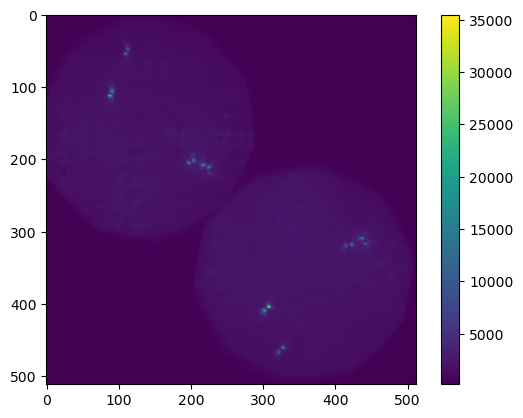

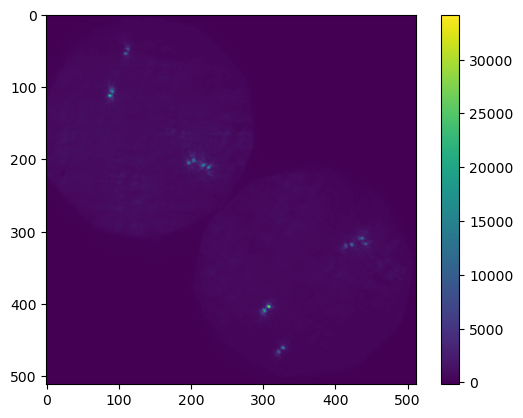

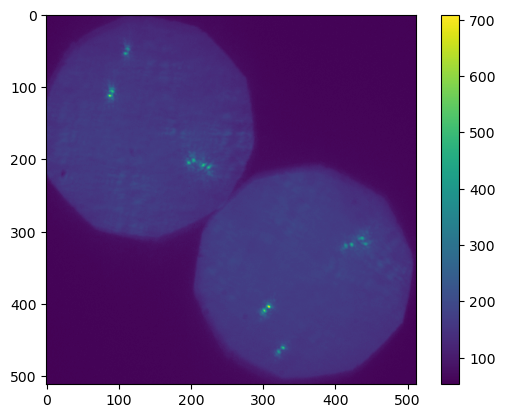

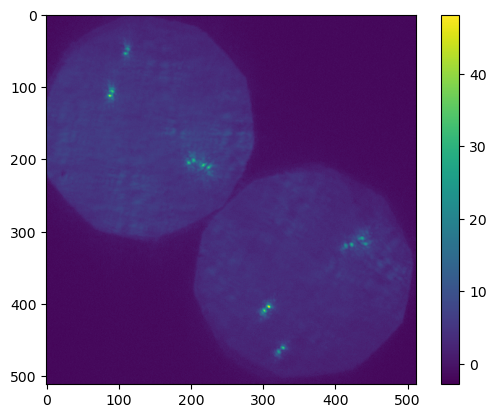

In [4]:
from PYME.localization.remFitBuf import fitTask

frame_num = 104

test_frame = np.squeeze(im.data_xytc[:,:,frame_num,0]).T
bg_subbed_frame = np.squeeze(bg_sub.data_xytc[:,:,frame_num,0]).T

# test_frame[test_frame<0] = 0
# bg_subbed_frame[bg_subbed_frame<0] = 0

plt.figure()
plt.imshow(test_frame)
plt.colorbar()

plt.figure()
plt.imshow(bg_subbed_frame)
plt.colorbar()


sigma = np.squeeze(fitTask.calcSigma(im.mdh, test_frame.astype('f')))
plt.figure()
plt.imshow(sigma)
plt.colorbar()

plt.figure()
plt.imshow(bg_subbed_frame/sigma)
plt.colorbar()

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x000001DAC0BD7850>


Optimization terminated successfully.
         Current function value: -0.013767
         Iterations: 15
         Function evaluations: 30


DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x000001DAC0BD5E10>


10.0


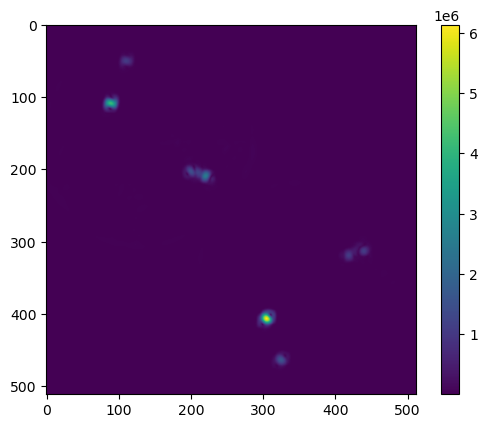

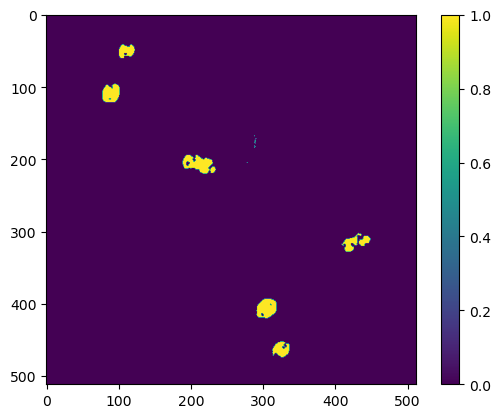

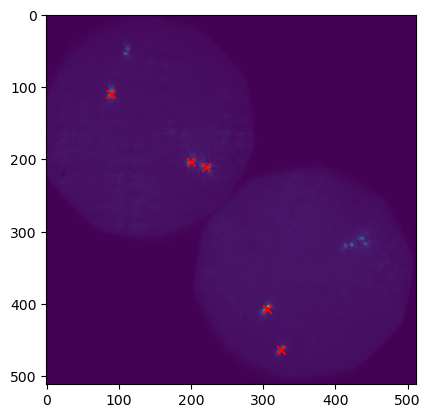

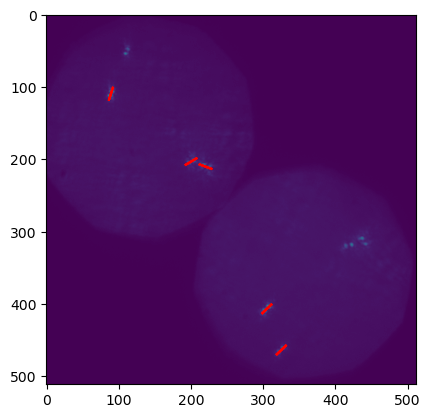

In [12]:
detector_new = new_detector(roi_half_size=10, l_initial=1000, lobe_sigma_initial=200, filter_sigma=5.0, px_size_nm=120)

strength_image_new, angle_image_new = detector_new.filter_frame(bg_subbed_frame)

plt.figure()
plt.imshow(strength_image_new)
plt.colorbar()

thresh = 20



plt.figure()
plt.imshow(strength_image_new>(thresh * sigma)**2 * detector_new.normFactor)
# plt.imshow(strength_image_new> thresh)
plt.colorbar()

row, col, orientation = detector_new.extract_candidates(strength_image_new, angle_image_new, (thresh * sigma)**2 * detector_new.normFactor)
# row, col, orientation = detector_new.extract_candidates(strength_image_new, angle_image_new, thresh)

def lobe_estimate_from_center_pixel(x_pix, y_pix, orientation, lobe_sep_px):
    dx = np.cos(orientation) * lobe_sep_px
    dy = np.sin(orientation) * lobe_sep_px
    x1 = x_pix - dx
    y1 = y_pix - dy
    x2 = x_pix + dx
    y2 = y_pix + dy
    return x1, y1, x2, y2

x1, y1, x2, y2 = lobe_estimate_from_center_pixel(col, row, orientation, 1025/120)

plt.figure()
plt.imshow(test_frame)
plt.scatter(col, row, marker='x', c='red')

plt.figure()
plt.imshow(test_frame)
for ii in range(len(row)):
    plt.plot([x1, x2], [y1, y2], 'r')

plt.show()

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x000001DAC002E250>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x000001DAC0087710>


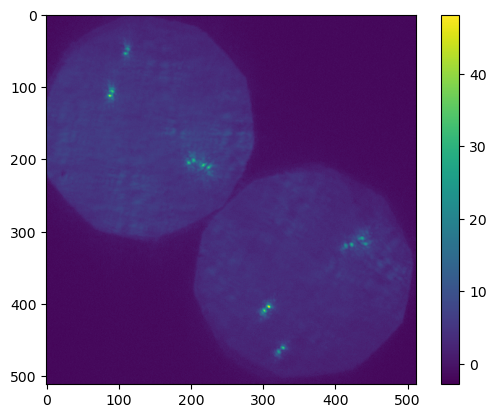

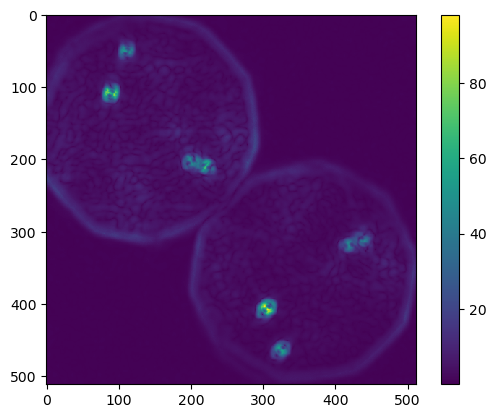

In [8]:
plt.figure()
plt.imshow(bg_subbed_frame/sigma)
plt.colorbar()

plt.figure()
plt.imshow(np.sqrt(strength_image_new/(detector_new.normFactor*sigma**2)), interpolation='nearest')
plt.colorbar()

In [9]:
np.shape((thresh * sigma)**2 * detector_new.normFactor)

(512, 512)

In [10]:

plt.figure()
plt.imshow(detector_new.max_filtered_strength)
plt.colorbar()

plt.figure()
plt.imshow(detector_new.max_filtered_threshold)
plt.colorbar()

plt.figure()
plt.imshow(detector_new.max_filtered_strength>(detector_new.max_filtered_threshold))
plt.colorbar()

AttributeError: 'Detector' object has no attribute 'max_filtered_strength'

<Figure size 640x480 with 0 Axes>